Import required libraries and read the dataset

---



In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("web_analytics_task_type_removed.csv")
df

Data Understanding

In [ ]:
# (1)	Core behavioral metrics
behavioral_vars = [
    "Avg. Session Duration (s)",
    "Pageviews",
    "Bounce Rate (%)",
    "Login_Frequency"
]
continuous_behavioral_vars = [
    "Avg. Session Duration (s)",
    "Bounce Rate (%)",
]
discrete_behavioral_vars = [
    "Pageviews",
    "Login_Frequency"
]

In [ ]:
engagement_summary = df[behavioral_vars].agg(
    ["mean", "median", "min", "max", "std"]
)

engagement_summary

In [ ]:
for col in continuous_behavioral_vars:
    plt.figure()
    plt.hist(df[col], bins=30, color="green")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [ ]:
# (2)	Access & platform characteristics
access_vars = [
    "Access_Platform",
    "Device_Category",
    "Operating System",
    "Browser",
    "Gender"
]

In [ ]:
for col in access_vars:
    print(f"\nFrequency and percentage table for {col}")

    freq_table = pd.DataFrame({
        "Count": df[col].value_counts(),
        "Percentage (%)": df[col].value_counts(normalize=True) * 100
    })

    print(freq_table.round(2))

In [ ]:
for col in access_vars:
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100

    plt.figure()
    bars = plt.bar(counts.index, counts.values, color="green")
    plt.xlabel(col)
    plt.ylabel("Number of Sessions")

    plt.xlabel(col)
    plt.ylabel("Number of Sessions")

    for i, bar in enumerate(bars):
        count = counts.values[i]
        percent = percentages.values[i]
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{count}\n({percent:.1f}%)",
            ha="center",
            va="bottom"
        )

    plt.show()

In [ ]:
counts = df["Access_Platform"].value_counts()
colors = ["#2ecc71", "#27ae60"]

plt.figure()
plt.pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors
)

plt.title("Access Platform Distribution")
plt.axis("equal")
plt.show()

In [ ]:
# (3)	System specific interaction variables

sis_vars = [
    "System_Module",
    "Task_Completion_Status"
]

for col in sis_vars:
    print(f"\nFrequency and percentage table for {col}")

    table = pd.DataFrame({
        "Count": df[col].value_counts(),
        "Percentage (%)": df[col].value_counts(normalize=True) * 100
    })

    print(table.round(2))


In [ ]:
module_completion = pd.crosstab(
    df["System_Module"],
    df["Task_Completion_Status"],
    normalize="index"
) * 100

module_completion.round(2)

In [ ]:
module_summary = df.groupby("System_Module")[
    ["Avg. Session Duration (s)", "Pageviews", "Error_Count"]
].mean()

module_summary.round(2)

Modelling (Classification)

In [ ]:
# Classification model
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [ ]:
# target variable (binary classification)
y = df["Task_Completion_Status"]

# predictive variables
X = df.drop(columns=["Task_Completion_Status"])

In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.30, random_state=42
)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Evaluation (Classification)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.89
Confusion Matrix:
 [[267   0]
 [ 33   0]]


In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.5457950289410964


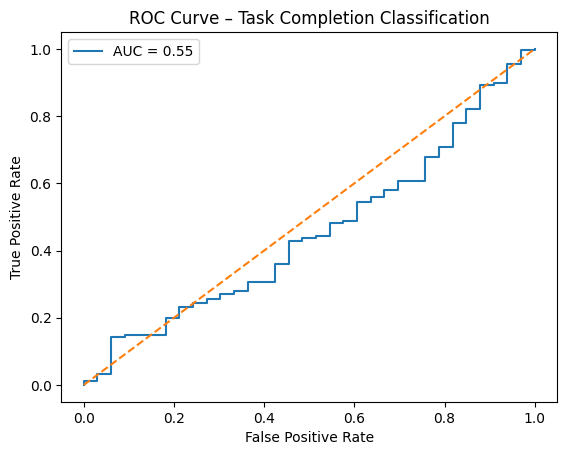

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label='Completed')

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Task Completion Classification")
plt.legend()
plt.show()

Modelling (Clustering)

In [ ]:
# Clustering model
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import sklearn.metrics as metrics

In [ ]:
X = df[
    [
        "Avg. Session Duration (s)",
        "Pageviews",
        "Bounce Rate (%)",
        "Login_Frequency",
        "Error_Count"
    ]
]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters
clusters

array([2, 1, 1, 2, 2, 1, 0, 1, 0, 2, 2, 1, 1, 0, 2, 2, 2, 2, 0, 2, 0, 2,
       1, 2, 2, 1, 2, 0, 1, 2, 1, 0, 2, 1, 0, 1, 1, 0, 1, 1, 2, 0, 2, 1,
       0, 2, 0, 1, 1, 0, 1, 2, 0, 1, 1, 1, 2, 0, 0, 1, 0, 1, 1, 2, 0, 0,
       2, 1, 0, 1, 1, 2, 2, 0, 0, 0, 1, 2, 1, 1, 1, 0, 1, 0, 2, 0, 1, 1,
       1, 2, 2, 0, 2, 0, 0, 2, 0, 0, 2, 0, 2, 0, 2, 0, 1, 2, 2, 1, 2, 2,
       0, 2, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 2, 0, 2, 1, 1, 0, 0, 2, 1, 2,
       2, 0, 1, 0, 0, 1, 2, 0, 1, 0, 0, 2, 2, 0, 1, 0, 2, 1, 0, 2, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 2, 2, 2, 2, 2, 1, 0, 2, 0, 2, 2, 2, 0, 0,
       1, 2, 1, 0, 2, 2, 1, 2, 2, 1, 0, 0, 0, 0, 2, 1, 1, 0, 1, 2, 1, 1,
       0, 0, 1, 2, 0, 0, 0, 2, 1, 1, 2, 2, 0, 0, 2, 0, 1, 0, 2, 0, 1, 1,
       0, 1, 2, 0, 2, 2, 0, 2, 2, 1, 1, 0, 1, 1, 2, 1, 1, 0, 0, 2, 1, 1,
       0, 0, 2, 2, 1, 1, 0, 1, 0, 0, 1, 0, 2, 0, 1, 1, 1, 0, 2, 1, 2, 0,
       1, 2, 2, 1, 0, 2, 1, 0, 0, 0, 0, 2, 0, 0, 1, 1, 1, 2, 2, 2, 0, 2,
       1, 1, 2, 1, 1, 0, 0, 1, 0, 1, 1, 2, 0, 2, 2,

In [ ]:
df["Cluster"].value_counts()

,count
Cluster,
0,376
1,328
2,296


In [ ]:
cluster_profiles = df.groupby("Cluster")[
    [
        "Avg. Session Duration (s)",
        "Pageviews",
        "Bounce Rate (%)",
        "Login_Frequency",
        "Error_Count"
    ]
].mean()

cluster_profiles.round(2)

,Avg. Session Duration (s),Pageviews,Bounce Rate (%),Login_Frequency,Error_Count
Cluster,,,,,
0,441.99,4.50,46.49,5.81,0.77
1,617.15,13.95,58.94,5.03,0.92
2,296.99,12.36,29.26,3.86,0.68


Evaluation (Clustering)

In [ ]:
sil_score = silhouette_score(X_scaled, df["Cluster"])
print("Silhouette Score for k=3:", sil_score)

Silhouette Score for k=3: 0.14104897981159262


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

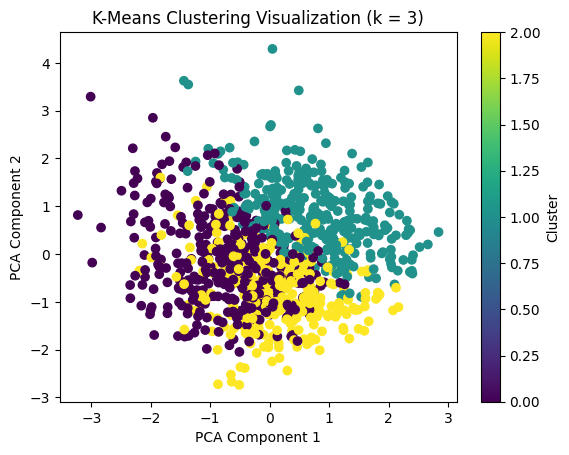

In [ ]:
plt.figure()

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["Cluster"],
    cmap="viridis"
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clustering Visualization (k = 3)")
plt.colorbar(label="Cluster")
plt.show()